<a href="https://colab.research.google.com/github/JingYang06522/DSTest/blob/main/trainmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [145]:
import pandas as pd

df = pd.read_csv("malaysia_house_price_data_2025_cleaned.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)


Dataset loaded successfully
Shape: (2318, 8)


In [146]:
X = df[['Area', 'State', 'Tenure', 'Type', 'Median_PSF', 'Transactions']]
y = df['Median_Price']

print("Features (X):", X.columns.tolist())
print("Target   (y):", y.name)
print()
print("X shape:", X.shape)
print("y shape:", y.shape)

Features (X): ['Area', 'State', 'Tenure', 'Type', 'Median_PSF', 'Transactions']
Target   (y): Median_Price

X shape: (2318, 6)
y shape: (2318,)


In [147]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print()
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (1854, 6)
y_train: (1854,)

X_test: (464, 6)
y_test: (464,)


In [148]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = ['Area', 'State', 'Tenure', 'Type']

numerical_features = ['Median_PSF', 'Transactions']

preprocessor = ColumnTransformer(
    transformers=[('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_features),
                  ('numerical', 'passthrough', numerical_features)]
)

print("Preprocessor created")
print("Categorical features:", categorical_features)
print("Numerical features  :", numerical_features)

Preprocessor created
Categorical features: ['Area', 'State', 'Tenure', 'Type']
Numerical features  : ['Median_PSF', 'Transactions']


In [149]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original  X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)
print()
print("Original  X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original  X_train shape: (1854, 6)
Processed X_train shape: (1854, 314)

Original  X_test shape: (464, 6)
Processed X_test shape: (464, 314)


In [150]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)
import numpy as np

In [151]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_processed, y_train)
y_pred_linear = linear_model.predict(X_test_processed)

print("Linear Regression training completed.")
print("Number of predictions:", len(y_pred_linear))

Linear Regression training completed.
Number of predictions: 464


In [152]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test,y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("====================================")
print("Linear Regression Results")
print("====================================")
print("MAE :", mae_linear)
print("MSE :", mse_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)
print("====================================")

Linear Regression Results
MAE : 122648.7209154298
MSE : 32678649413.220272
RMSE: 180772.3690535151
R²  : 0.7386624725731297


In [173]:
from sklearn.linear_model import Ridge

tuned_linear_model = Ridge(
    alpha=10.0
)

tuned_linear_model.fit(
    X_train_processed,
    y_train
)

y_pred_tuned_linear = tuned_linear_model.predict(
    X_test_processed
)

print("Tuned Linear Regression training completed.")

Tuned Linear Regression training completed.


In [174]:
mae_tuned_linear = mean_absolute_error(y_test, y_pred_tuned_linear)
mse_tuned_linear = mean_squared_error(y_test, y_pred_tuned_linear)
rmse_tuned_linear = np.sqrt(mse_tuned_linear)
r2_tuned_linear = r2_score(y_test, y_pred_tuned_linear)

print("====================================")
print("Tuned Linear Regression Results")
print("====================================")
print("MAE :", mae_tuned_linear)
print("MSE :", mse_tuned_linear)
print("RMSE:", rmse_tuned_linear)
print("R²  :", r2_tuned_linear)
print("====================================")

Tuned Linear Regression Results
MAE : 114468.05206234897
MSE : 28811702312.0059
RMSE: 169740.10225048734
R²  : 0.7695872020912667


In [153]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(random_state=42, max_depth=10, min_samples_split=10, min_samples_leaf=5)
tree_model.fit(X_train_processed, y_train)
y_pred_tree = tree_model.predict(X_test_processed)

print("Decision Tree Regression training completed.")
print("Number of predictions:", len(y_pred_tree))

Decision Tree Regression training completed.
Number of predictions: 464


In [154]:
mae_tree = mean_absolute_error(y_test,y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("====================================")
print("Decision Tree Results")
print("====================================")
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE:", rmse_tree)
print("R²  :", r2_tree)
print("====================================")

Decision Tree Results
MAE : 125216.75972713855
MSE : 43944229042.477806
RMSE: 209628.78867769524
R²  : 0.6485694369610266


In [175]:
tuned_tree_model = DecisionTreeRegressor(
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

tuned_tree_model.fit(
    X_train_processed,
    y_train
)

y_pred_tuned_tree = tuned_tree_model.predict(
    X_test_processed
)

print("Tuned Decision Tree training completed.")

Tuned Decision Tree training completed.


In [176]:
mae_tuned_tree = mean_absolute_error(y_test, y_pred_tuned_tree)
mse_tuned_tree = mean_squared_error(y_test, y_pred_tuned_tree)
rmse_tuned_tree = np.sqrt(mse_tuned_tree)
r2_tuned_tree = r2_score(y_test, y_pred_tuned_tree)

print("====================================")
print("Tuned Decision Tree Results")
print("====================================")
print("MAE :", mae_tuned_tree)
print("MSE :", mse_tuned_tree)
print("RMSE:", rmse_tuned_tree)
print("R²  :", r2_tuned_tree)
print("====================================")

Tuned Decision Tree Results
MAE : 124839.26684738741
MSE : 43037779073.55661
RMSE: 207455.48696902816
R²  : 0.6558184940018661


In [155]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)


y_pred_rf = random_forest_model.predict(
    X_test_processed
)

print("Random Forest Regression training completed.")
print("Number of predictions:", len(y_pred_rf))

Random Forest Regression training completed.
Number of predictions: 464


In [156]:
mae_rf = mean_absolute_error(
    y_test,
    y_pred_rf
)

mse_rf = mean_squared_error(
    y_test,
    y_pred_rf
)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(
    y_test,
    y_pred_rf
)
print("====================================")
print("Random Forest Results")
print("====================================")
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)
print("====================================")

Random Forest Results
MAE : 102907.49709870009
MSE : 28048795080.711113
RMSE: 167477.74503112677
R²  : 0.7756883198872183


In [157]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    loss='squared_error'
)

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

y_pred_gb = gradient_boosting_model.predict(
    X_test_processed
)

print("Gradient Boosting Regression training completed.")
print("Number of predictions:", len(y_pred_gb))

Gradient Boosting Regression training completed.
Number of predictions: 464


In [158]:
mae_gb = mean_absolute_error(
    y_test,
    y_pred_gb
)

mse_gb = mean_squared_error(
    y_test,
    y_pred_gb
)

rmse_gb = np.sqrt(mse_gb)

r2_gb = r2_score(
    y_test,
    y_pred_gb
)
print("====================================")
print("Gradient Boosting Results")
print("====================================")
print("MAE :", mae_gb)
print("MSE :", mse_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)
print("====================================")

Gradient Boosting Results
MAE : 107510.04286889153
MSE : 35926728808.92317
RMSE: 189543.4747199786
R²  : 0.7126869486943566


In [177]:
tuned_gb_model = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    loss='squared_error'
)

tuned_gb_model.fit(
    X_train_processed,
    y_train
)

y_pred_tuned_gb = tuned_gb_model.predict(
    X_test_processed
)

print("Tuned Gradient Boosting training completed.")

Tuned Gradient Boosting training completed.


In [178]:
mae_tuned_gb = mean_absolute_error(y_test, y_pred_tuned_gb)
mse_tuned_gb = mean_squared_error(y_test, y_pred_tuned_gb)
rmse_tuned_gb = np.sqrt(mse_tuned_gb)
r2_tuned_gb = r2_score(y_test, y_pred_tuned_gb)

print("====================================")
print("Tuned Gradient Boosting Results")
print("====================================")
print("MAE :", mae_tuned_gb)
print("MSE :", mse_tuned_gb)
print("RMSE:", rmse_tuned_gb)
print("R²  :", r2_tuned_gb)
print("====================================")

Tuned Gradient Boosting Results
MAE : 105300.68863309418
MSE : 30505370950.29261
RMSE: 174657.86827478633
R²  : 0.7560426039466683


In [159]:
y_train_pred_rf = random_forest_model.predict(X_train_processed)

train_r2_rf = r2_score(y_train, y_train_pred_rf)

test_r2_rf = r2_score(y_test, y_pred_rf)

print("====================================")
print("Random Forest R² Comparison")
print("====================================")
print("Training R²:", train_r2_rf)
print("Testing R² :", test_r2_rf)
print("Difference :", train_r2_rf - test_r2_rf)
print("====================================")

Random Forest R² Comparison
Training R²: 0.8896990921071705
Testing R² : 0.7756883198872183
Difference : 0.11401077221995215


In [160]:
tuned_rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

tuned_rf_model.fit(X_train_processed, y_train)

y_pred_tuned_rf = tuned_rf_model.predict(X_test_processed)

print("Tuned Random Forest training completed.")

Tuned Random Forest training completed.


In [161]:
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
rmse_tuned_rf = np.sqrt(mse_tuned_rf)
r2_tuned_rf = r2_score(y_test,y_pred_tuned_rf)

print("====================================")
print("Tuned Random Forest Results")
print("====================================")
print("MAE :", mae_tuned_rf)
print("MSE :", mse_tuned_rf)
print("RMSE:", rmse_tuned_rf)
print("R²  :", r2_tuned_rf)
print("====================================")

Tuned Random Forest Results
MAE : 106462.4500385694
MSE : 27201249074.194714
RMSE: 164928.0117936147
R²  : 0.7824663104621258


In [162]:
y_train_pred_tuned_rf = tuned_rf_model.predict(X_train_processed)
train_r2_tuned_rf = r2_score(y_train, y_train_pred_tuned_rf)

print("Training R²:", train_r2_tuned_rf)
print("Testing R² :", r2_tuned_rf)
print("Difference :", train_r2_tuned_rf - r2_tuned_rf)

Training R²: 0.7846629783539898
Testing R² : 0.7824663104621258
Difference : 0.0021966678918640126


In [163]:
feature_names = preprocessor.get_feature_names_out()

importance_values = random_forest_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 20 Most Important Features:")
display(feature_importance.head(20))

Top 20 Most Important Features:


,Feature,Importance
312,numerical__Median_PSF,0.662004
313,numerical__Transactions,0.051574
304,categorical__Type_BUNGALOW,0.049789
309,categorical__Type_SERVICE RESIDENCE,0.030178
308,categorical__Type_SEMI D,0.025091
303,categorical__Type_APARTMENT,0.024865
307,categorical__Type_FLAT,0.020839
66,categorical__Area_DAMANSARA HEIGHTS,0.014585
310,categorical__Type_TERRACE HOUSE,0.011572
164,categorical__Area_MONT KIARA,0.009733


In [164]:
prediction_results = pd.DataFrame({
    'Actual_Price': y_test.values,
    'Predicted_Price': y_pred_rf
})

prediction_results['Error'] = (
    prediction_results['Actual_Price']
    - prediction_results['Predicted_Price']
)

prediction_results['Absolute_Error'] = (
    prediction_results['Error'].abs()
)

print("Prediction Results:")
display(prediction_results.head(10))

print("Average Error:",
      prediction_results['Error'].mean())

print("Average Absolute Error:",
      prediction_results['Absolute_Error'].mean())

print("Largest Absolute Error:",
      prediction_results['Absolute_Error'].max())

Prediction Results:


,Actual_Price,Predicted_Price,Error,Absolute_Error
0,234000.0,3.549461e+05,-120946.129353,120946.129353
1,1565000.0,1.114013e+06,450986.849750,450986.849750
2,839000.0,1.084356e+06,-245355.577810,245355.577810
3,235000.0,2.648853e+05,-29885.346821,29885.346821
4,115000.0,1.765878e+05,-61587.841089,61587.841089
5,293000.0,3.830738e+05,-90073.754750,90073.754750
6,262500.0,2.894607e+05,-26960.734774,26960.734774
7,733750.0,4.123874e+05,321362.630306,321362.630306
8,1260000.0,1.117057e+06,142942.699631,142942.699631
9,260000.0,2.677438e+05,-7743.824959,7743.824959


Average Error: -8796.56578041403
Average Absolute Error: 102907.49709870009
Largest Absolute Error: 1437771.0442222226


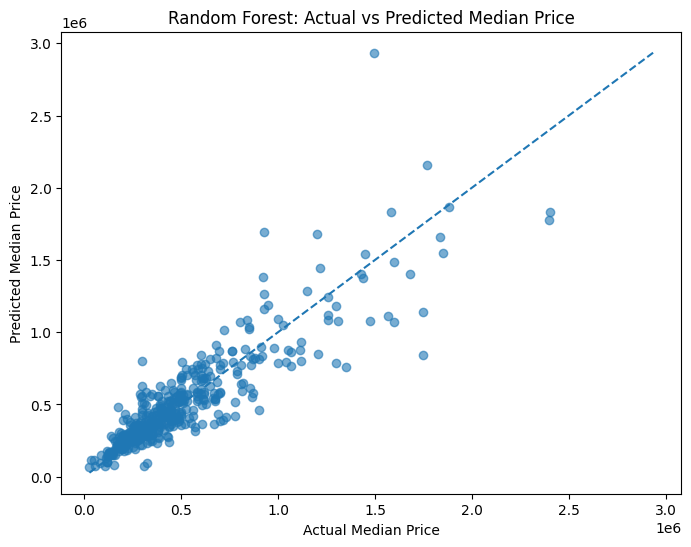

In [165]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.6
)

# Perfect prediction line
min_price = min(y_test.min(), y_pred_rf.min())
max_price = max(y_test.max(), y_pred_rf.max())

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle='--'
)

plt.xlabel("Actual Median Price")
plt.ylabel("Predicted Median Price")
plt.title("Random Forest: Actual vs Predicted Median Price")

plt.show()

In [166]:
import joblib

model_bundle = {
    'preprocessor': preprocessor,
    'models': {
        'Linear Regression': linear_model,
        'Decision Tree': tree_model,
        'Random Forest': random_forest_model,
        'Gradient Boosting': gradient_boosting_model
    },
    'metrics': {
        'Linear Regression': {
            'MAE': mae_linear,
            'MSE': mse_linear,
            'RMSE': rmse_linear,
            'R2': r2_linear
        },
        'Decision Tree': {
            'MAE': mae_tree,
            'MSE': mse_tree,
            'RMSE': rmse_tree,
            'R2': r2_tree
        },
        'Random Forest': {
            'MAE': mae_rf,
            'MSE': mse_rf,
            'RMSE': rmse_rf,
            'R2': r2_rf
        },
        'Gradient Boosting': {
            'MAE': mae_gb,
            'MSE': mse_gb,
            'RMSE': rmse_gb,
            'R2': r2_gb
        }
    }
}
joblib.dump(
    model_bundle,
    'malaysia_house_price_models.joblib'
)

print("====================================")
print("ALL MODELS SAVED SUCCESSFULLY")
print("====================================")
print("File: malaysia_house_price_models.joblib")
print("Models saved:")

for model_name in model_bundle['models']:
    print("-", model_name)

ALL MODELS SAVED SUCCESSFULLY
File: malaysia_house_price_models.joblib
Models saved:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [167]:
loaded_bundle = joblib.load('malaysia_house_price_models.joblib')

print("Model bundle loaded successfully!")
print("\nAvailable models:")
for model_name in loaded_bundle['models']:
    print("-", model_name)

print("\nStored metrics:")
print(pd.DataFrame(loaded_bundle['metrics']).T)


Model bundle loaded successfully!

Available models:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting

Stored metrics:
                             MAE           MSE           RMSE        R2
Linear Regression  122648.720915  3.267865e+10  180772.369054  0.738662
Decision Tree      125216.759727  4.394423e+10  209628.788678  0.648569
Random Forest      102907.497099  2.804880e+10  167477.745031  0.775688
Gradient Boosting  107510.042869  3.592673e+10  189543.474720  0.712687
